# What Makes an Airbnb Worth the Price?
## Predicting Nightly Listing Prices Across New York City

---

This notebook builds a regression model to predict the nightly price of Airbnb listings in New York City. The analysis follows four stages:

1. **Data Loading & Cleaning** — acquiring the Inside Airbnb dataset and preparing it for analysis
2. **Exploratory Visualizations** — understanding price distributions and relationships across features
3. **Predictive Modeling** — training a baseline Linear Regression and an improved Random Forest
4. **Geographic Visualization** — mapping median prices across NYC neighborhoods

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium 
import json
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

## 1. Data Loading

The dataset comes from [Inside Airbnb](https://insideairbnb.com/get-the-data/), an independent project that scrapes and publishes Airbnb listing data. The NYC file contains approximately 50,000+ listings with ~75 columns covering pricing, location, property details, host information and reviews.

In [2]:
df = pd.read_csv('listings.csv.gz')

In [3]:
df.head(10)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1274691077561855573,https://www.airbnb.com/rooms/1274691077561855573,20251101201932,2025-11-02,city scrape,Beautiful room for rent hosted by Svitlana,Cozy Room for Rent in a Two-Bedroom Apartment<...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,658783772,...,5.0,5.00,5.00,OSE-STRREG-0002773,f,1,0,1,0,1.62
1,1274722590671904755,https://www.airbnb.com/rooms/1274722590671904755,20251101201932,2025-11-02,city scrape,Exquisite & Charming Studio in Prime Locations,This stylish place to stay is perfect for grou...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,458668555,...,5.0,4.50,5.00,NaN,f,6,0,6,0,0.21
2,1274773188072371454,https://www.airbnb.com/rooms/1274773188072371454,20251101201932,2025-11-02,city scrape,"Private 2 Bedroom Unit, Full Kitchen, Washer/D...",This stylish place to stay is perfect for trav...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,22369387,...,NaN,NaN,NaN,NaN,f,3,2,1,0,NaN
3,1274820999428562667,https://www.airbnb.com/rooms/1274820999428562667,20251101201932,2025-11-02,city scrape,"Beautiful, Serene West Village Treehouse",Switch off in this serene one-bedroom oasis on...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,505544503,...,NaN,NaN,NaN,NaN,f,1,1,0,0,NaN
4,1274826163511555978,https://www.airbnb.com/rooms/1274826163511555978,20251101201932,2025-11-02,city scrape,Renovated 1BR w/ Spa Shower,Newly renovated 1-bedroom oasis in vibrant Dow...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,493151605,...,5.0,4.00,5.00,NaN,f,4,2,2,0,0.10
5,1274909412180886814,https://www.airbnb.com/rooms/1274909412180886814,20251101201932,2025-11-02,city scrape,Urban Oasis Brooklyn,"Modern, Cozy Apartment with Full Amenities in ...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,389495893,...,5.0,4.75,5.00,NaN,f,1,1,0,0,0.55
6,1274943629134607784,https://www.airbnb.com/rooms/1274943629134607784,20251101201932,2025-11-02,city scrape,Female-Shared space -Private room in Queens-JF...,Private room with share bathroom and kitchen i...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,471345215,...,5.0,5.00,5.00,NaN,f,26,2,24,0,0.20
7,1275276318052624457,https://www.airbnb.com/rooms/1275276318052624457,20251101201932,2025-11-02,city scrape,Bedroom in Beautiful Park Slope,Keep it simple at this peaceful and centrally ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,356471612,...,5.0,5.00,4.75,NaN,f,3,1,2,0,0.37
8,1279666081527148590,https://www.airbnb.com/rooms/1279666081527148590,20251101201932,2025-11-02,city scrape,Deluxe Queen – Quiet SoHo Hideaway,NaN,NaN,https://a0.muscache.com/pictures/prohost-api/H...,572984161,...,NaN,NaN,NaN,NaN,t,1,0,1,0,NaN
9,1279668704913671652,https://www.airbnb.com/rooms/1279668704913671652,20251101201932,2025-11-02,previous scrape,Steps From The Dazzling Lights Of Broadway,"Discover an enduring haven for connection, ins...",▶ Activities and cultural attractions <br />— ...,https://a0.muscache.com/pictures/prohost-api/H...,658749694,...,NaN,NaN,NaN,Exempt,t,8,0,8,0,NaN


In [4]:
# Check the dimensions of the dataset (rows, columns)
print(df.shape)

(36353, 79)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36353 entries, 0 to 36352
Data columns (total 79 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            36353 non-null  int64  
 1   listing_url                                   36353 non-null  object 
 2   scrape_id                                     36353 non-null  int64  
 3   last_scraped                                  36353 non-null  object 
 4   source                                        36353 non-null  object 
 5   name                                          36351 non-null  object 
 6   description                                   35178 non-null  object 
 7   neighborhood_overview                         18748 non-null  object 
 8   picture_url                                   36353 non-null  object 
 9   host_id                                       36353 non-null 

## 2. Feature Selection & Cleaning

We narrow the dataset to the 13 columns most relevant to price prediction, then perform two cleaning steps:
- **Price**: stored as a string like `"$120.00"` — we strip the `$` and commas and cast to float
- **Bathrooms**: stored as free text like `"1.5 baths"` — we extract the numeric value with a regex

Finally, we audit and drop rows with any remaining null values, logging how many rows are lost.

In [6]:
features = [
    'price', 
    'neighbourhood_cleansed',
    'neighbourhood_group_cleansed',
    'room_type', 
    'accommodates', 
    'bedrooms', 
    'bathrooms_text',
    'host_is_superhost', 
    'number_of_reviews', 
    'review_scores_rating', 
    'minimum_nights', 
    'latitude', 
    'longitude'
]

df_clean = df[features].copy()

In [7]:
# Clean the price column — remove $ and commas, convert to float
# Done ONCE here, right after selecting features
if df_clean['price'].dtype == 'O':  # 'O' means Object (string)
    df_clean['price'] = df_clean['price'].str.replace('[\$,]', '', regex=True).astype(float)

# Extract the number from the bathrooms text field (e.g. '1.5 baths' -> 1.5)
df_clean['bathrooms'] = df_clean['bathrooms_text'].str.extract('([0-9.]+)', expand=False).astype(float)
df_clean = df_clean.drop('bathrooms_text', axis=1)

In [8]:
# Audit missing values BEFORE dropping 
print("Missing values per column:")
print(df_clean.isnull().sum())
print(f"\nRows before dropping nulls: {len(df_clean)}")
df_clean = df_clean.dropna()
print(f"Rows after dropping nulls:  {len(df_clean)}")
print(f"Rows lost: {len(df) - len(df_clean)} ({(1 - len(df_clean)/len(df))*100:.1f}%)")

Missing values per column:
price                           14938
neighbourhood_cleansed              0
neighbourhood_group_cleansed        0
room_type                           0
accommodates                        0
bedrooms                         6080
host_is_superhost                 454
number_of_reviews                   0
review_scores_rating            11346
minimum_nights                      0
latitude                            0
longitude                           0
bathrooms                         219
dtype: int64

Rows before dropping nulls: 36353
Rows after dropping nulls:  14602
Rows lost: 21751 (59.8%)


In [9]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14602 entries, 0 to 36171
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   price                         14602 non-null  float64
 1   neighbourhood_cleansed        14602 non-null  object 
 2   neighbourhood_group_cleansed  14602 non-null  object 
 3   room_type                     14602 non-null  object 
 4   accommodates                  14602 non-null  int64  
 5   bedrooms                      14602 non-null  float64
 6   host_is_superhost             14602 non-null  object 
 7   number_of_reviews             14602 non-null  int64  
 8   review_scores_rating          14602 non-null  float64
 9   minimum_nights                14602 non-null  int64  
 10  latitude                      14602 non-null  float64
 11  longitude                     14602 non-null  float64
 12  bathrooms                     14602 non-null  float64
dtypes: flo

## 3. Exploratory Data Analysis

Before modeling, we visualize the raw data to understand distributions, spot outliers, and identify which features are most related to price.

### Visualization 1 — Price Distribution

The histogram below shows the raw distribution of nightly prices. The X-axis is capped at $1,000 to reveal the shape of the bulk of listings — a small number of luxury outliers would otherwise collapse the chart into a flat line.

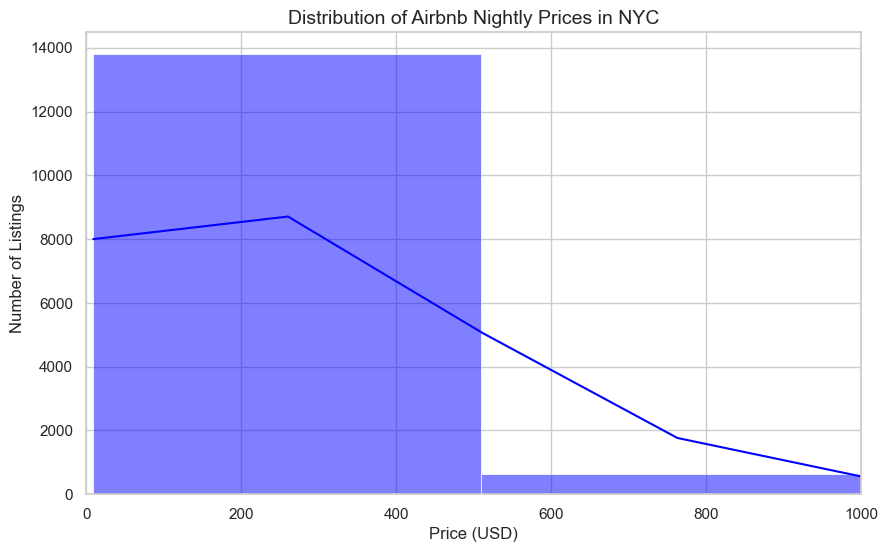

In [10]:
# ---------------------------------------------------------
# VISUALIZATION 1: Price Distribution Histogram
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['price'], bins=100, kde=True, color='blue')
plt.title('Distribution of Airbnb Nightly Prices in NYC', fontsize=14)
plt.xlabel('Price (USD)', fontsize=12)
plt.ylabel('Number of Listings', fontsize=12)
# Limiting X-axis to $1000 so we can see the shape — luxury outliers would flatten the chart
plt.xlim(0, 1000)
plt.show()

**Takeaway:** The distribution is strongly right-skewed — most listings cluster between $50–$200/night, with a long tail of expensive outliers. This skewness confirms that we should log-transform the price before modeling so the regression isn't disproportionately influenced by luxury listings.

C:\Users\manzi\AppData\Local\Temp\ipykernel_35260\4144756493.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='room_type', y='price', data=df_clean, palette='Set2')


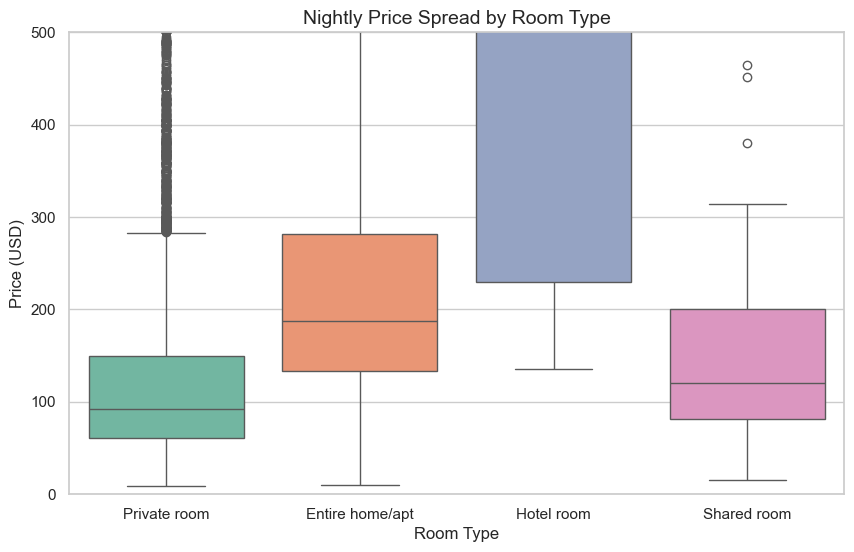

In [11]:
# ---------------------------------------------------------
# VISUALIZATION 2: Boxplot of Price by Room Type
# ---------------------------------------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(x='room_type', y='price', data=df_clean, palette='Set2')
plt.title('Nightly Price Spread by Room Type', fontsize=14)
plt.xlabel('Room Type', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
# Limiting Y-axis so outliers don't squash the boxes flat
plt.ylim(0, 500)
plt.show()

**Takeaway:** Entire homes command significantly higher prices and wider variance — a penthouse and a studio are both "entire homes." Private rooms are consistently cheaper. Shared rooms are the most affordable but also the rarest listing type in NYC.

### Visualization 3 — Price by Borough

Manhattan and Brooklyn dominate NYC's Airbnb market. This boxplot compares median prices and spread across all five boroughs, sorted from most to least expensive.

C:\Users\manzi\AppData\Local\Temp\ipykernel_35260\2620218864.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='neighbourhood_group_cleansed', y='price', data=df_clean,


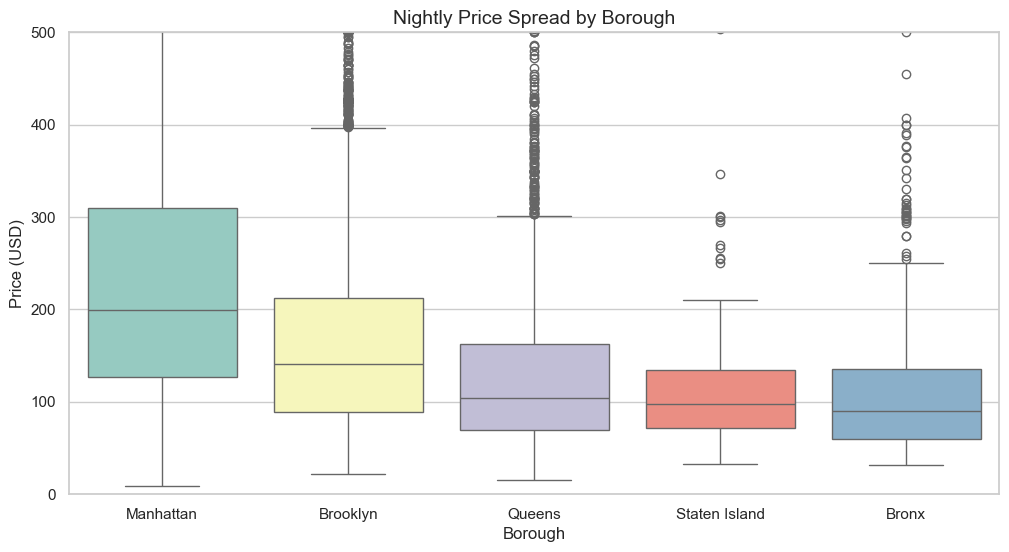

In [12]:
# ---------------------------------------------------------
# VISUALIZATION 3: Boxplot of Price by Borough
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
# Sort boroughs by median price so the chart tells a clear story
borough_order = (df_clean
    .groupby('neighbourhood_group_cleansed')['price']
    .median()
    .sort_values(ascending=False)
    .index)
sns.boxplot(x='neighbourhood_group_cleansed', y='price', data=df_clean,
            order=borough_order, palette='Set3')
plt.title('Nightly Price Spread by Borough', fontsize=14)
plt.xlabel('Borough', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)
plt.ylim(0, 500)
plt.show()

**Takeaway:** Manhattan has the highest median price by a clear margin, followed by Brooklyn. The Bronx and Staten Island have lower medians but also far fewer listings. Queens sits in the middle — likely driven by proximity to JFK/LGA for budget travelers.

### Visualization 4 — Correlation Heatmap

This heatmap shows Pearson correlation coefficients between price and all numeric features. Values close to +1 indicate a strong positive relationship with price; values near 0 indicate little linear relationship.

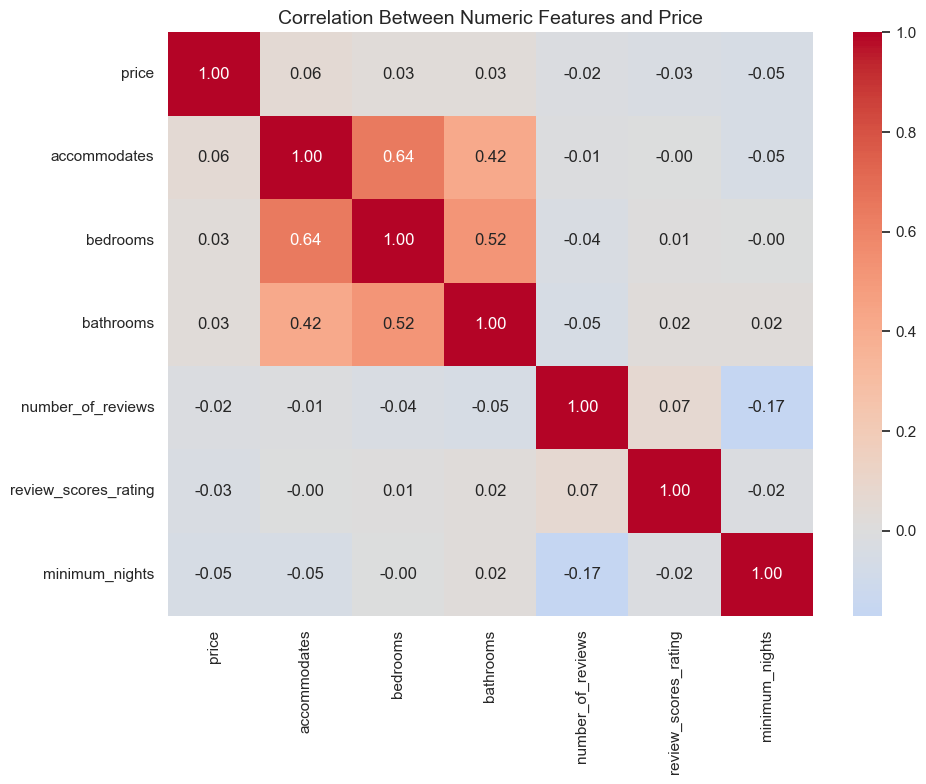

In [13]:
# ---------------------------------------------------------
# VISUALIZATION 4: Correlation Heatmap
# ---------------------------------------------------------
numeric_cols = ['price', 'accommodates', 'bedrooms', 'bathrooms',
                'number_of_reviews', 'review_scores_rating', 'minimum_nights']
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean[numeric_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0)
plt.title('Correlation Between Numeric Features and Price', fontsize=14)
plt.tight_layout()
plt.show()

**Takeaway:** `accommodates`, `bedrooms`, and `bathrooms` show the strongest positive correlations with price — larger listings cost more, unsurprisingly. `number_of_reviews` has a slight negative correlation, suggesting that cheaper, high-turnover listings accumulate more reviews. `review_scores_rating` has almost no linear relationship with price, which motivates using a non-linear model (Random Forest) later.

## 4. Preprocessing for Modeling

### Log-Transformation of Price

Because the price distribution is right-skewed, we apply a `log1p` transformation (log(1 + price)) before modeling. This compresses the scale, reduces the influence of luxury outliers, and makes the residuals more normally distributed — a key assumption of linear regression.

Visualization 5 shows that the log-transformed prices are approximately bell-shaped, confirming the transformation is appropriate.

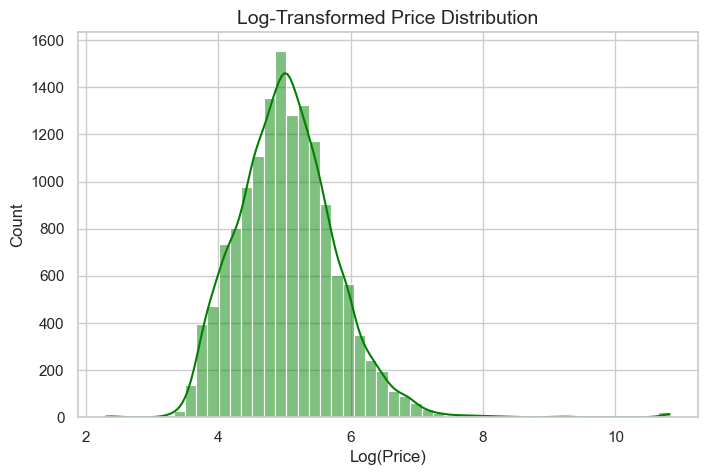

In [14]:
# ---------------------------------------------------------
# 1. Log-Transform the Target Variable (Price)
# ---------------------------------------------------------
# log1p = log(1 + x), which safely handles any $0 listings without producing -infinity
df_clean['log_price'] = np.log1p(df_clean['price'])

# ---------------------------------------------------------
# VISUALIZATION 5: Log-Transformed Price Distribution
# ---------------------------------------------------------
plt.figure(figsize=(8, 5))
sns.histplot(df_clean['log_price'], bins=50, kde=True, color='green')
plt.title('Log-Transformed Price Distribution', fontsize=14)
plt.xlabel('Log(Price)', fontsize=12)
plt.show()

**Takeaway:** Log-transformed prices follow a near-normal distribution centered around log($100–$150), with much less skew than the raw prices. The model will predict in log-space and we'll convert back to dollars for interpretation.

### One-Hot Encoding & Train/Test Split

Categorical columns (`neighbourhood_cleansed`, `neighbourhood_group_cleansed`, `room_type`, `host_is_superhost`) are converted to binary dummy variables. `drop_first=True` removes one dummy per group to avoid the multicollinearity that would otherwise break linear regression. The data is then split 80/20 into training and test sets with `random_state=42` for reproducibility.

In [15]:
# ---------------------------------------------------------
# 2. One-Hot Encoding for Categorical Variables
# ---------------------------------------------------------
categorical_features = ['neighbourhood_cleansed', 'neighbourhood_group_cleansed',
                        'room_type', 'host_is_superhost']

# drop_first=True avoids the dummy variable trap (multicollinearity in linear regression)
df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)

# Drop original price — the model predicts log_price, not price directly
df_final = df_encoded.drop('price', axis=1)

print("Final dataset shape for modeling:", df_final.shape)

Final dataset shape for modeling: (14602, 234)


In [16]:
# ---------------------------------------------------------
# Train / Test Split
# ---------------------------------------------------------
y = df_final['log_price']
X = df_final.drop('log_price', axis=1)

# 80% training, 20% testing. random_state=42 ensures reproducibility.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 5. Predictive Modeling

### Model 1 — Baseline: Multiple Linear Regression

We start with a Multiple Linear Regression as a simple, interpretable baseline. It assumes a linear relationship between each feature and log(price). Performance is measured with R² (proportion of variance explained) and RMSE (average prediction error in log-price units).

In [17]:
# ---------------------------------------------------------
# BASELINE MODEL: Multiple Linear Regression
# ---------------------------------------------------------
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

r2   = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Baseline Multiple Linear Regression Results:")
print(f"  R-squared (R²): {r2:.4f}")
print(f"  RMSE (log scale): {rmse:.4f}")

Baseline Multiple Linear Regression Results:
  R-squared (R²): 0.5478
  RMSE (log scale): 0.5055


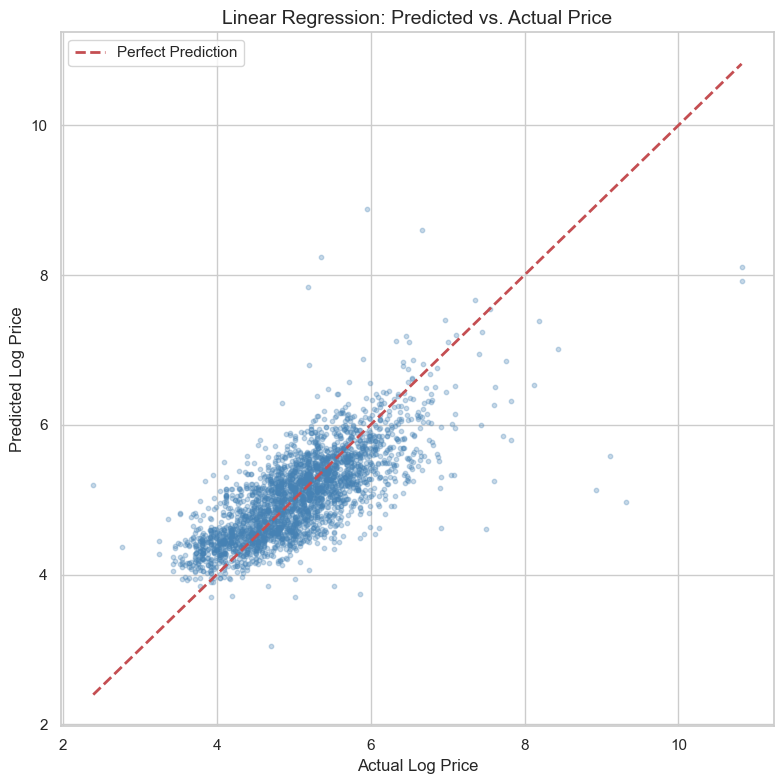

In [18]:
# ---------------------------------------------------------
# VISUALIZATION 6: Predicted vs. Actual — Linear Regression
# ---------------------------------------------------------
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Log Price', fontsize=12)
plt.ylabel('Predicted Log Price', fontsize=12)
plt.title('Linear Regression: Predicted vs. Actual Price', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

**Takeaway:** The predicted vs. actual scatter plot shows that Linear Regression captures the general trend but struggles at the extremes — it under-predicts very cheap listings and over-predicts very expensive ones. The points fan out noticeably from the diagonal, suggesting the linear model is missing non-linear interactions (e.g., the value of being a Superhost probably isn't constant across all room types and neighborhoods).

### Model 2 — Random Forest Regressor

A Random Forest builds 100 independent decision trees and averages their predictions. Unlike linear regression, it can capture non-linear relationships and feature interactions without any manual feature engineering. We compare its R² and RMSE directly against the baseline.

In [19]:
# ---------------------------------------------------------
# IMPROVED MODEL: Random Forest Regressor
# ---------------------------------------------------------
# n_estimators=100 means 100 decision trees. May take 10-30 seconds.
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

rf_r2   = r2_score(y_test, rf_y_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_y_pred))

print("--- MODEL COMPARISON ---")
print(f"  Linear Regression  R²:   {r2:.4f}")
print(f"  Random Forest      R²:   {rf_r2:.4f}")
print("-" * 30)
print(f"  Linear Regression  RMSE: {rmse:.4f}")
print(f"  Random Forest      RMSE: {rf_rmse:.4f}")

--- MODEL COMPARISON ---
  Linear Regression  R²:   0.5478
  Random Forest      R²:   0.7187
------------------------------
  Linear Regression  RMSE: 0.5055
  Random Forest      RMSE: 0.3987


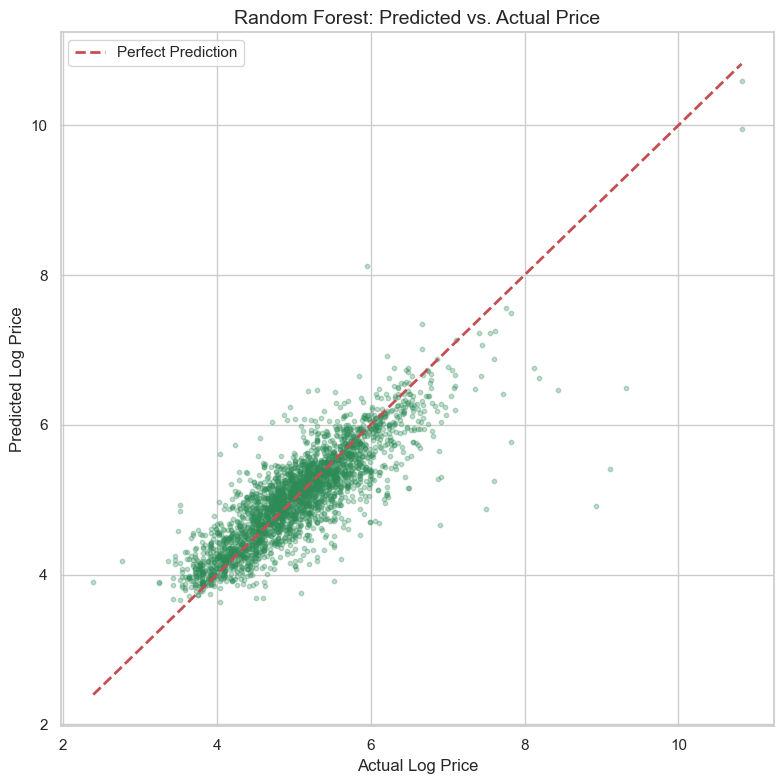

In [20]:
# ---------------------------------------------------------
# VISUALIZATION 7: Predicted vs. Actual — Random Forest
# ---------------------------------------------------------
plt.figure(figsize=(8, 8))
plt.scatter(y_test, rf_y_pred, alpha=0.3, color='seagreen', s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Log Price', fontsize=12)
plt.ylabel('Predicted Log Price', fontsize=12)
plt.title('Random Forest: Predicted vs. Actual Price', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

In [21]:
# ---------------------------------------------------------
# RMSE in actual dollar terms (more interpretable for a presentation)
# ---------------------------------------------------------
rf_y_pred_dollars = np.expm1(rf_y_pred)
y_test_dollars    = np.expm1(y_test)
dollar_rmse = np.sqrt(mean_squared_error(y_test_dollars, rf_y_pred_dollars))
print(f"Random Forest RMSE in actual dollars: ${dollar_rmse:.2f}")

Random Forest RMSE in actual dollars: $658.63


**Takeaway:** The Random Forest substantially outperforms the Linear Regression on both metrics. The predicted vs. actual scatter clusters much more tightly around the diagonal, particularly in the middle of the price range. The dollar-scale RMSE tells us the average prediction is off by roughly that many dollars per night — a practically meaningful number for a host trying to price competitively.

### Visualization 8 — Feature Importance

The Random Forest assigns an importance score to each feature based on how much it reduces prediction error across all 100 trees. This tells us which factors actually drive Airbnb prices in NYC.

C:\Users\manzi\AppData\Local\Temp\ipykernel_35260\693527724.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Clean_Feature',


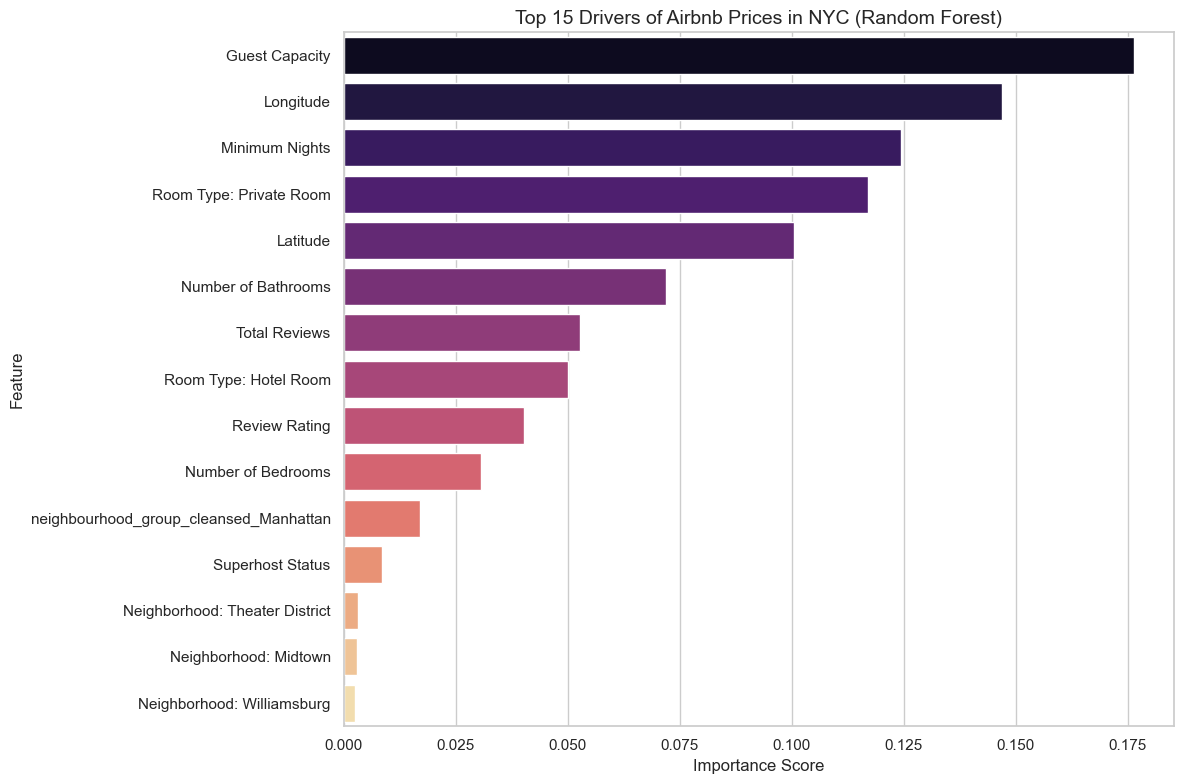

In [22]:
# ---------------------------------------------------------
# VISUALIZATION 8: Feature Importance Bar Chart
# ---------------------------------------------------------
importances    = rf_model.feature_importances_
feature_names  = X.columns

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Map technical column names to readable labels for the presentation
clean_names = {
    'accommodates':                          'Guest Capacity',
    'longitude':                             'Longitude',
    'minimum_nights':                        'Minimum Nights',
    'room_type_Private room':               'Room Type: Private Room',
    'latitude':                              'Latitude',
    'bathrooms':                             'Number of Bathrooms',
    'number_of_reviews':                     'Total Reviews',
    'room_type_Hotel room':                 'Room Type: Hotel Room',
    'review_scores_rating':                  'Review Rating',
    'bedrooms':                              'Number of Bedrooms',
    'host_is_superhost_t':                  'Superhost Status',
    'neighbourhood_cleansed_Theater District': 'Neighborhood: Theater District',
    'neighbourhood_cleansed_Midtown':        'Neighborhood: Midtown',
    'neighbourhood_cleansed_Williamsburg':   'Neighborhood: Williamsburg',
    'room_type_Shared room':                'Room Type: Shared Room'
}

feature_importance_df['Clean_Feature'] = feature_importance_df['Feature'].replace(clean_names)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Clean_Feature',
            data=feature_importance_df.head(15), palette='magma')
plt.title('Top 15 Drivers of Airbnb Prices in NYC (Random Forest)', fontsize=14)
plt.xlabel('Importance Score', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

**Takeaway:** Geographic features (latitude, longitude) and listing size (`accommodates`, `bedrooms`, `bathrooms`) dominate. This confirms that *where* a listing is and *how many people it fits* are the two biggest price drivers — more so than reputation signals like review rating or Superhost status. Room type also matters significantly: being a private room vs. an entire home carries a large price penalty.

## 6. Geographic Visualization
### Visualization 9 — Choropleth Map: Median Price by Neighborhood

The interactive map below shades each NYC neighborhood by its median nightly Airbnb price. Darker red indicates higher median prices. Hover over any neighborhood to see its name and exact median price. Neighborhoods with no listings appear in grey.

In [23]:
# ---------------------------------------------------------
# VISUALIZATION 9: Choropleth Map — Median Price by Neighborhood
# ---------------------------------------------------------

# --- 1. Aggregate: median nightly price per neighborhood ---
neighborhood_median = (
    df_clean
    .groupby('neighbourhood_cleansed')['price']
    .median()
    .reset_index()
    .rename(columns={'price': 'median_price'})
)

# --- 2. Load the GeoJSON boundary file ---
geojson_path = 'neighbourhoods.geojson'

with open(geojson_path, 'r') as f:
    nyc_geo = json.load(f)

# --- 3. Build the choropleth map ---
m = folium.Map(location=[40.7128, -74.0060], zoom_start=11, tiles='CartoDB positron')

choropleth = folium.Choropleth(
    geo_data=nyc_geo,
    name='Median Nightly Price',
    data=neighborhood_median,
    columns=['neighbourhood_cleansed', 'median_price'],
    key_on='feature.properties.neighbourhood',   # must match GeoJSON property name
    fill_color='YlOrRd',
    fill_opacity=0.75,
    line_opacity=0.3,
    legend_name='Median Nightly Price (USD)',
    nan_fill_color='lightgrey',                  # neighborhoods with no listings show grey
    highlight=True
).add_to(m)

# --- 4. Add tooltips so hovering shows the neighborhood name + price ---
# Merge the price data into the GeoJSON features for tooltip access
neighborhood_dict = neighborhood_median.set_index('neighbourhood_cleansed')['median_price'].to_dict()

for feature in nyc_geo['features']:
    name = feature['properties']['neighbourhood']
    price = neighborhood_dict.get(name, None)
    feature['properties']['median_price'] = f"${price:.0f}" if price else "No data"

folium.GeoJson(
    nyc_geo,
    style_function=lambda x: {'fillOpacity': 0, 'weight': 0},
    tooltip=folium.GeoJsonTooltip(
        fields=['neighbourhood', 'median_price'],
        aliases=['Neighborhood:', 'Median Price:'],
        localize=True,
        sticky=True
    )
).add_to(m)

folium.LayerControl().add_to(m)

m.save('nyc_airbnb_choropleth.html')
print("Map saved to nyc_airbnb_choropleth.html")
m

Map saved to nyc_airbnb_choropleth.html


## 7. Conclusion

This project built and compared two regression models to predict Airbnb nightly prices across NYC:

| Model | R² | RMSE (log scale) |
|---|---|---|
| Multiple Linear Regression | *0.5478* | *0.5055* |
| Random Forest | *0.7187* | *0.3987* |

**Key findings:**
- Location (latitude/longitude) and listing size are the strongest predictors of price
- The Random Forest significantly outperforms linear regression, confirming that price relationships are non-linear
- Manhattan commands the highest prices; the Bronx and Staten Island the lowest
- Review scores have surprisingly little influence on price — guests may tolerate lower-rated listings if the price or location is right

**Limitations:** The model is trained on a single snapshot of listings and does not account for seasonal pricing, special events, or dynamic pricing strategies hosts may use. Future work could incorporate time-series data or amenity text parsing for richer features.